# Implementation de Grad-CAM vidéo natif avec S3D/I3D-like.

## Objectif scientifique de cette baseline

Cette baseline correspond à **Grad-CAM vidéo natif avec S3D/I3D-like**.

Le modèle S3D est fine-tuné sur UCF101 pour obtenir une accuracy comparable aux autres approches. Ensuite, Grad-CAM est appliqué **post-hoc** sur les features vidéo du backbone.

Important : cette méthode ne contient **pas** de LSTM, pas d’attention, pas de Transformer et pas de contraintes d’explicabilité. Elle sert uniquement à évaluer l’axe spatial : **où le modèle regarde**.

# Phase 1 — Imports, configuration et chemins Kaggle

On importe les bibliothèques, on définit les chemins UCF101, les hyperparamètres, et les paramètres d’évaluation spatiale.

In [15]:
import os
import cv2
import json
import random
import shutil
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.video import s3d, S3D_Weights, r3d_18, R3D_18_Weights

try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from IPython.display import Video, display, HTML, FileLink
except Exception:
    Video = None
    display = print
    HTML = lambda x: x
    FileLink = lambda x: x

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


@dataclass
class CFG:
    data_root: str = "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition"
    backbone_name: str = "s3d"   # "s3d" recommended; "r3d_18" fallback.
    pretrained: bool = True
    num_classes: int = 101
    clip_len: int = 32
    frame_size: int = 224
    batch_size: int = 2
    num_workers: int = 2
    epochs: int = 8
    lr: float = 1e-4
    weight_decay: float = 1e-4
    freeze_backbone_epochs: int = 1
    spatial_top_ratio: float = 0.25
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42
    output_dir: str = "./xai_outputs_native_video_gradcam_s3d_spatial"
    checkpoint_every_batches: int = 500


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def split_dirs(cfg: CFG):
    return {
        "train": os.path.join(cfg.data_root, "train"),
        "val": os.path.join(cfg.data_root, "val"),
        "test": os.path.join(cfg.data_root, "test"),
    }


VIDEO_EXTS = (".avi", ".mp4", ".mov", ".mkv")

# Phase 2 — Dataset UCF101 vidéo

Cette classe lit les vidéos depuis la structure Kaggle `train/val/test/<classe>/*.avi`, extrait un clip de longueur fixe, redimensionne les frames et applique la normalisation attendue par S3D.

In [16]:
class UCF101VideoFolderDataset(Dataset):
    def __init__(self, root_dir: str, clip_len: int = 32, frame_size: int = 224, train: bool = False, class_to_idx: Optional[Dict[str, int]] = None):
        self.root_dir = root_dir
        self.clip_len = clip_len
        self.frame_size = frame_size
        self.train = train

        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = class_to_idx if class_to_idx is not None else {c: i for i, c in enumerate(classes)}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

        self.samples = []
        for class_name in classes:
            if class_name not in self.class_to_idx:
                continue
            class_dir = os.path.join(root_dir, class_name)
            for f in sorted(os.listdir(class_dir)):
                if f.lower().endswith(VIDEO_EXTS):
                    self.samples.append((os.path.join(class_dir, f), self.class_to_idx[class_name], class_name))

        self.normalize = transforms.Normalize(
            mean=[0.43216, 0.394666, 0.37645],
            std=[0.22803, 0.22145, 0.216989],
        )

    def __len__(self):
        return len(self.samples)

    def _read_video(self, path: str) -> List[np.ndarray]:
        cap = cv2.VideoCapture(path)
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()
        return frames

    def _sample_indices(self, n: int) -> np.ndarray:
        if n <= 0:
            return np.zeros(self.clip_len, dtype=np.int64)
        if n >= self.clip_len:
            if self.train:
                start = random.randint(0, max(0, n - self.clip_len))
                return np.arange(start, start + self.clip_len)
            return np.linspace(0, n - 1, self.clip_len).astype(np.int64)
        return np.linspace(0, n - 1, self.clip_len).astype(np.int64)

    def _preprocess(self, frames: List[np.ndarray]):
        idx = self._sample_indices(len(frames))
        sampled = []
        for i in idx:
            fr = frames[int(i)] if len(frames) else np.zeros((self.frame_size, self.frame_size, 3), dtype=np.uint8)
            fr = cv2.resize(fr, (self.frame_size, self.frame_size))
            if self.train and random.random() < 0.5:
                fr = cv2.flip(fr, 1)
            sampled.append(fr)

        arr = np.stack(sampled).astype(np.float32) / 255.0
        raw = torch.from_numpy(arr).permute(3, 0, 1, 2).float()  # C,T,H,W in [0,1]
        x = raw.clone()
        for t in range(x.shape[1]):
            x[:, t] = self.normalize(x[:, t])
        return x, raw

    def __getitem__(self, idx: int):
        path, y, class_name = self.samples[idx]
        frames = self._read_video(path)
        x, raw = self._preprocess(frames)
        return {
            "video": x,
            "raw_video": raw,
            "label": torch.tensor(y, dtype=torch.long),
            "path": path,
            "class_name": class_name,
        }


# Phase 3 — Construction des datasets et dataloaders

On construit les loaders train/validation/test en gardant le même mapping `class_to_idx` pour éviter toute incohérence entre splits.

In [17]:
def build_datasets(cfg: CFG):
    dirs = split_dirs(cfg)
    train_ds = UCF101VideoFolderDataset(dirs["train"], cfg.clip_len, cfg.frame_size, train=True)
    val_ds = UCF101VideoFolderDataset(dirs["val"], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=train_ds.class_to_idx)
    test_ds = UCF101VideoFolderDataset(dirs["test"], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=train_ds.class_to_idx)
    print(f"Train videos: {len(train_ds)} | Val videos: {len(val_ds)} | Test videos: {len(test_ds)}")
    print(f"Classes: {len(train_ds.class_to_idx)}")
    return train_ds, val_ds, test_ds


def build_loaders(cfg: CFG):
    train_ds, val_ds, test_ds = build_datasets(cfg)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


# Phase 4 — Modèle de classification vidéo S3D/I3D-like

Grad-CAM n’est pas un modèle entraînable. Ici, on entraîne seulement le classifieur vidéo S3D sur UCF101 afin que ses prédictions soient comparables aux autres approches.

In [18]:
class NativeVideoClassifier(nn.Module):
    """Plain S3D/I3D-like video classifier. No LSTM, no attention, no XAI constraints."""
    def __init__(self, num_classes=101, backbone_name="s3d", pretrained=True):
        super().__init__()
        self.backbone_name = backbone_name
        if backbone_name == "s3d":
            weights = S3D_Weights.DEFAULT if pretrained else None
            base = s3d(weights=weights)
            self.features = base.features
            self.feat_dim = 1024
        elif backbone_name == "r3d_18":
            weights = R3D_18_Weights.DEFAULT if pretrained else None
            base = r3d_18(weights=weights)
            self.features = nn.Sequential(base.stem, base.layer1, base.layer2, base.layer3, base.layer4)
            self.feat_dim = 512
        else:
            raise ValueError("backbone_name must be 's3d' or 'r3d_18'")
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.feat_dim, num_classes))

    def forward(self, x, return_features=False):
        feats = self.features(x)  # [B,C,T',H',W']
        if feats.requires_grad:
            feats.retain_grad()
        pooled = feats.mean(dim=(2, 3, 4))
        logits = self.classifier(pooled)
        if return_features:
            return logits, feats
        return logits


def set_backbone_trainable(model: NativeVideoClassifier, trainable: bool):
    for p in model.features.parameters():
        p.requires_grad = trainable


@torch.no_grad()
def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def save_checkpoint(path, model, optimizer, epoch, best_val_acc, cfg, class_to_idx):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "best_val_acc": best_val_acc,
        "cfg": asdict(cfg),
        "class_to_idx": class_to_idx,
    }, path)
    print("Checkpoint sauvegardé:", path)


def load_checkpoint(path, model, optimizer=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model"] if "model" in ckpt else ckpt["model_state_dict"]
    model.load_state_dict(state, strict=True)
    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = int(ckpt.get("epoch", -1)) + 1
    best_val_acc = float(ckpt.get("best_val_acc", -1))
    return ckpt, start_epoch, best_val_acc


# Phase 5 — Entraînement et validation du classifieur

Boucles d’entraînement classiques avec sauvegarde `last`, `best` et `batch_safety_checkpoint` pour éviter de perdre le progrès dans Kaggle.

In [19]:
def train_one_epoch(model, loader, optimizer, cfg: CFG, epoch: int):
    model.train()
    set_backbone_trainable(model, epoch >= cfg.freeze_backbone_epochs)
    losses, accs = [], []
    for batch_idx, batch in enumerate(tqdm(loader, desc="train")):
        video = batch["video"].to(cfg.device)
        labels = batch["label"].to(cfg.device)
        logits = model(video)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
        accs.append(accuracy_from_logits(logits.detach(), labels))
        if cfg.checkpoint_every_batches and (batch_idx + 1) % cfg.checkpoint_every_batches == 0:
            save_checkpoint(os.path.join(cfg.output_dir, "batch_safety_checkpoint.pt"), model, optimizer, epoch, -1, cfg, loader.dataset.class_to_idx)
    return {"loss": float(np.mean(losses)), "acc": float(np.mean(accs))}


@torch.no_grad()
def validate(model, loader, cfg: CFG):
    model.eval()
    losses, accs = [], []
    for batch in tqdm(loader, desc="valid"):
        video = batch["video"].to(cfg.device)
        labels = batch["label"].to(cfg.device)
        logits = model(video)
        loss = F.cross_entropy(logits, labels)
        losses.append(float(loss.cpu()))
        accs.append(accuracy_from_logits(logits, labels))
    return {"val_loss": float(np.mean(losses)), "val_acc": float(np.mean(accs))}


def train_classifier_main(resume_from: Optional[str] = None):
    cfg = CFG()
    seed_everything(cfg.seed)
    os.makedirs(cfg.output_dir, exist_ok=True)
    train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = build_loaders(cfg)
    model = NativeVideoClassifier(cfg.num_classes, cfg.backbone_name, cfg.pretrained).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    start_epoch = 0
    best_val_acc = -1.0
    if resume_from is not None and os.path.exists(resume_from):
        ckpt, start_epoch, best_val_acc = load_checkpoint(resume_from, model, optimizer, cfg.device)
        print(f"Reprise depuis epoch index {start_epoch}. Best val_acc précédent: {best_val_acc:.4f}")
    history = []
    for epoch in range(start_epoch, cfg.epochs):
        tr = train_one_epoch(model, train_loader, optimizer, cfg, epoch)
        va = validate(model, val_loader, cfg)
        row = {"epoch": epoch + 1, **tr, **va}
        history.append(row)
        print(f"Epoch {epoch+1}/{cfg.epochs} | train={tr} | valid={va}")
        save_checkpoint(os.path.join(cfg.output_dir, "last_checkpoint.pt"), model, optimizer, epoch, best_val_acc, cfg, train_ds.class_to_idx)
        if va["val_acc"] > best_val_acc:
            best_val_acc = va["val_acc"]
            save_checkpoint(os.path.join(cfg.output_dir, "best_native_video_gradcam_s3d_spatial.pt"), model, optimizer, epoch, best_val_acc, cfg, train_ds.class_to_idx)
        pd.DataFrame(history).to_csv(os.path.join(cfg.output_dir, "training_history.csv"), index=False)
    return model, optimizer, cfg


# Phase 6 — Grad-CAM vidéo natif 3D post-hoc

On calcule Grad-CAM sur les feature maps spatio-temporelles `[C,T,H,W]` du backbone S3D. La heatmap obtenue est spatiale et projetée sur chaque frame. Il n’y a pas d’attention temporelle ni de mécanisme dynamique appris.

In [20]:
class NativeVideoGradCAM3D:
    """
    Native Grad-CAM on S3D features. It returns only spatial heatmaps per frame.
    Any temporal variation exists because heatmaps are frame-indexed, but this baseline
    does not claim to explain temporal decision-making.
    """
    def __init__(self, model: NativeVideoClassifier):
        self.model = model

    def __call__(self, video: torch.Tensor, class_idx: Optional[int] = None):
        self.model.eval()
        video = video.clone().detach().to(next(self.model.parameters()).device)
        video.requires_grad_(True)
        logits, feats = self.model(video, return_features=True)
        probs = torch.softmax(logits, dim=1)
        if class_idx is None:
            class_idx = int(probs.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        self.model.zero_grad(set_to_none=True)
        grads = torch.autograd.grad(score, feats, retain_graph=False, create_graph=False)[0]
        weights = grads.mean(dim=(2, 3, 4), keepdim=True)
        cam = (weights * feats).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam_up = F.interpolate(cam, size=(video.shape[2], video.shape[3], video.shape[4]), mode="trilinear", align_corners=False)
        heatmap = cam_up[0, 0].detach().cpu().numpy()  # [T,H,W]
        return heatmap, class_idx, float(probs[0, class_idx].detach().cpu())


# Phase 7 — Visualisation vidéo originale et vidéo expliquée

On génère une vidéo avec overlay heatmap. Le cadre rouge indique simplement les frames où l’intensité moyenne de la heatmap est forte ; ce n’est pas une attention temporelle apprise.

In [34]:
def denormalize_video(x: torch.Tensor) -> np.ndarray:
    if x.max() <= 1.0 and x.min() >= 0.0:
        y = x.detach().cpu().clamp(0, 1)
    else:
        mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
        std = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)
        y = x.detach().cpu() * std + mean
        y = y.clamp(0, 1)
    return (y.permute(1, 2, 3, 0).numpy() * 255).astype(np.uint8)


def overlay_heatmap(frame_rgb: np.ndarray, heat: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    heat_uint = np.uint8(255 * np.clip(heat, 0, 1))
    color = cv2.applyColorMap(heat_uint, cv2.COLORMAP_JET)
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(frame_rgb, 1 - alpha, color, alpha, 0)


def save_explanation_video(sample, heatmap, pred_text, prob, save_path, fps=8):
    frames = denormalize_video(sample["raw_video"] if "raw_video" in sample else sample["video"])
    T, H, W, _ = frames.shape
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    writer = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    for t in range(T):
        frame = overlay_heatmap(frames[t], heatmap[t])
        cv2.putText(frame, f"Prediction: {pred_text} ({prob:.2f})", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(frame, "Native S3D Grad-CAM spatial baseline", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255,255,255), 2, cv2.LINE_AA)
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    writer.release()
    return save_path


def save_original_video(sample, save_path, fps=8):
    frames = denormalize_video(sample["raw_video"] if "raw_video" in sample else sample["video"])
    T, H, W, _ = frames.shape
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    writer = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    for t in range(T):
        writer.write(cv2.cvtColor(frames[t], cv2.COLOR_RGB2BGR))
    writer.release()
    return save_path


def convert_to_web_mp4(input_path, output_path):
    os.system(f'ffmpeg -y -i "{input_path}" -vcodec libx264 -pix_fmt yuv420p -f mp4 "{output_path}" -loglevel quiet')
    return output_path


def show_original_and_explanation(report, sample, width=750):
    original_path = os.path.join(os.path.dirname(report["output_video"]), "original_tmp.mp4")
    original_web = os.path.join(os.path.dirname(report["output_video"]), "original_web.mp4")
    explained_web = report["output_video"].replace(".mp4", "_web.mp4")
    save_original_video(sample, original_path)
    convert_to_web_mp4(original_path, original_web)
    convert_to_web_mp4(report["output_video"], explained_web)
    if Video is None:
        print("Video display unavailable")
        return
    print("Vidéo originale")
    display(Video(original_web, embed=True, width=width))
    print("Vidéo expliquée")
    display(Video(explained_web, embed=True, width=width))
    display(HTML(f"""
    <div style="font-family: Arial; max-width: 850px;">
      <h3>Explication Grad-CAM Natif - Baseline spatiale</h3>
      <b>Ground truth:</b> {report['ground_truth']}<br>
      <b>Prediction:</b> {report['prediction']}<br>
      <b>Correct:</b> {report['correct']}<br>
      <b>Confidence:</b> {report['probability']:.4f}<br>
      <h4>Métriques spatiales</h4>
      <b>spatial_drop:</b> {report['sp_drop']:.4f}<br>
      <b>sparsity:</b> {report['sparsity']:.4f}<br>
      <b>motion_overlap:</b> {report['motion_overlap']:.4f}<br>
    </div>
    """))


# Phase 8 — Métriques spatiales uniquement

Pour cette baseline, on évalue seulement l’explication spatiale : deletion drop, sparsity, et overlap avec le mouvement comme proxy spatial. Aucune métrique temporelle n’est utilisée.

In [22]:
def compute_motion_map(raw_video: torch.Tensor) -> np.ndarray:
    arr = raw_video.detach().cpu().permute(1, 2, 3, 0).numpy()
    gray = arr.mean(axis=-1)
    motion = np.zeros_like(gray)
    motion[1:] = np.abs(gray[1:] - gray[:-1])
    motion = motion / (motion.max() + 1e-8)
    return motion


def spatial_heatmap_sparsity(heatmap: np.ndarray, threshold_ratio: float = 0.6) -> float:
    """Percentage of low-activation pixels. Higher means more focused/sparse heatmap."""
    hm = heatmap / (heatmap.max() + 1e-8)
    active_ratio = float((hm >= threshold_ratio).mean())
    return 1.0 - active_ratio


def spatial_motion_overlap_proxy(heatmap: np.ndarray, raw_video: torch.Tensor) -> float:
    """Spatial proxy only: overlap between heatmap and frame-difference motion map."""
    motion = compute_motion_map(raw_video)
    hm = heatmap / (heatmap.max() + 1e-8)
    return float((hm * motion).sum() / (hm.sum() + 1e-8))


def spatial_deletion_drop(model, video, label, heatmap, top_ratio=0.25):
    """
    Spatial fidelity proxy. Masks top heatmap pixels in every frame and measures target probability drop.
    Higher drop = more spatially faithful explanation.
    """
    model.eval()
    device = next(model.parameters()).device
    video = video.to(device)
    label_int = int(label.item())
    with torch.no_grad():
        base_prob = torch.softmax(model(video), dim=1)[0, label_int].item()
    hm = torch.from_numpy(heatmap).float().to(device)  # [T,H,W]
    T, H, W = hm.shape
    flat = hm.view(T, -1)
    k = max(1, int(H * W * top_ratio))
    idx = torch.topk(flat, k=k, dim=1).indices
    mask = torch.zeros_like(flat)
    mask.scatter_(1, idx, 1.0)
    mask = mask.view(1, 1, T, H, W)
    deleted = video.clone()
    deleted = deleted * (1.0 - mask)
    with torch.no_grad():
        deleted_prob = torch.softmax(model(deleted), dim=1)[0, label_int].item()
    return float(base_prob - deleted_prob)


# Phase 9 — Chargement checkpoint, explication d’un sample et évaluation complète

Fonctions pour charger le meilleur modèle, expliquer une vidéo, évaluer tout le split test, puis produire un résumé global/par classe.

In [27]:
def find_available_checkpoint(output_dir: str = "./xai_outputs_native_video_gradcam_s3d_spatial"):
    candidates = [
        os.path.join(output_dir, "best_native_video_gradcam_s3d_spatial.pt"),
        os.path.join(output_dir, "last_checkpoint.pt"),
        os.path.join(output_dir, "native_gradcam_s3d_model.pt"),
    ]
    for c in candidates:
        if os.path.exists(c):
            print("Checkpoint utilisé:", c)
            return c
    raise FileNotFoundError(f"Aucun checkpoint trouvé dans {output_dir}")


def load_model_for_inference(checkpoint_path: str, cfg: CFG):
    ckpt = torch.load(checkpoint_path, map_location=cfg.device)
    class_to_idx = ckpt.get("class_to_idx", None)
    model = NativeVideoClassifier(cfg.num_classes, cfg.backbone_name, pretrained=False).to(cfg.device)
    state = ckpt["model"] if "model" in ckpt else ckpt["model_state_dict"]
    model.load_state_dict(state, strict=True)
    model.eval()
    return model, class_to_idx, ckpt


def get_dataset_for_split(cfg: CFG, split: str, class_to_idx=None):
    return UCF101VideoFolderDataset(split_dirs(cfg)[split], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=class_to_idx)


def explain_one_sample(checkpoint_path: str, sample_index: int = 0, split: str = "test"):
    cfg = CFG()
    os.makedirs(cfg.output_dir, exist_ok=True)
    model, class_to_idx, ckpt = load_model_for_inference(checkpoint_path, cfg)
    dataset = get_dataset_for_split(cfg, split, class_to_idx=class_to_idx)
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    sample = dataset[sample_index]
    video = sample["video"].unsqueeze(0).to(cfg.device)
    label = sample["label"].to(cfg.device)
    gradcam = NativeVideoGradCAM3D(model)
    heatmap, pred_idx, prob = gradcam(video)
    pred_text = idx_to_class.get(pred_idx, str(pred_idx))
    sp_drop = spatial_deletion_drop(model, video, label, heatmap, cfg.spatial_top_ratio)
    sparsity = spatial_heatmap_sparsity(heatmap)
    motion_overlap = spatial_motion_overlap_proxy(heatmap, sample["raw_video"])
    save_path = os.path.join(cfg.output_dir, f"explanation_{split}_{sample_index}_{pred_text}.mp4")
    save_explanation_video(sample, heatmap, pred_text, prob, save_path)
    report = {
        "split": split,
        "sample_index": sample_index,
        "video_path": sample["path"],
        "ground_truth": sample["class_name"],
        "prediction": pred_text,
        "correct": bool(pred_text == sample["class_name"]),
        "probability": float(prob),
        "output_video": save_path,
        "sp_drop": sp_drop,
        "sparsity": sparsity,
        "motion_overlap": motion_overlap
        
    }
    print(json.dumps(report, indent=2, ensure_ascii=False))
    return report, sample


def evaluate_full_split(checkpoint_path: str, split: str = "test", max_samples: Optional[int] = None):
    cfg = CFG()
    os.makedirs(os.path.join(cfg.output_dir, "full_evaluation"), exist_ok=True)
    model, class_to_idx, ckpt = load_model_for_inference(checkpoint_path, cfg)
    dataset = get_dataset_for_split(cfg, split, class_to_idx=class_to_idx)
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    gradcam = NativeVideoGradCAM3D(model)
    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    rows = []
    for i in tqdm(range(n), desc=f"Evaluation {split}"):
        try:
            sample = dataset[i]
            video = sample["video"].unsqueeze(0).to(cfg.device)
            label = sample["label"].to(cfg.device)
            heatmap, pred_idx, prob = gradcam(video)
            pred_text = idx_to_class.get(pred_idx, str(pred_idx))
            rows.append({
                "index": i,
                "video_path": sample["path"],
                "ground_truth": sample["class_name"],
                "prediction": pred_text,
                "correct": bool(pred_text == sample["class_name"]),
                "probability": float(prob),
            })
        except Exception as e:
            rows.append({"index": i, "error": str(e), "correct": False})
    df = pd.DataFrame(rows)
    path = os.path.join(cfg.output_dir, "full_evaluation", f"{split}_spatial_metrics.csv")
    df.to_csv(path, index=False)
    print("Métriques sauvegardées:", path)
    return df


def summarize_results(df: pd.DataFrame):
    cfg = CFG()
    out = os.path.join(cfg.output_dir, "full_evaluation")
    os.makedirs(out, exist_ok=True)
    df_ok = df[df.get("error").isna()] if "error" in df.columns else df.copy()
    metrics = [
        "probability",
    ]
    summary = {"num_samples": len(df_ok), "accuracy": float(df_ok["correct"].mean())}
    for m in metrics:
        summary[f"{m}_mean"] = float(df_ok[m].mean())
        summary[f"{m}_std"] = float(df_ok[m].std())
        summary[f"{m}_median"] = float(df_ok[m].median())
        summary[f"{m}_min"] = float(df_ok[m].min())
        summary[f"{m}_max"] = float(df_ok[m].max())
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(os.path.join(out, "summary_global_spatial_metrics.csv"), index=False)
    class_summary = df_ok.groupby("ground_truth").agg(
        n=("ground_truth", "count"),
        accuracy=("correct", "mean"),
        confidence_mean=("probability", "mean"),
    ).reset_index().sort_values("accuracy")
    class_summary.to_csv(os.path.join(out, "summary_by_class_spatial_metrics.csv"), index=False)
    print("Diagnostic global")
    print("-----------------")
    print(f"Accuracy globale: {summary['accuracy']:.4f}")
    return summary_df, class_summary


# Phase 10 — Plots et export des résultats

On sauvegarde les graphiques, checkpoints, métriques CSV, vidéos et éventuellement un Kaggle Dataset privé.

In [24]:
def plot_diagnostics(df: pd.DataFrame, class_summary: Optional[pd.DataFrame] = None):
    if plt is None:
        print("matplotlib unavailable")
        return
    cfg = CFG()
    out = os.path.join(cfg.output_dir, "full_evaluation")
    os.makedirs(out, exist_ok=True)
    df_ok = df[df.get("error").isna()] if "error" in df.columns else df.copy()
    cols = [
        ("probability", "Distribution de la confiance"),
    ]
    for col, title in cols:
        plt.figure(figsize=(8, 5))
        plt.hist(df_ok[col].dropna(), bins=40)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Nombre de vidéos")
        path = os.path.join(out, f"hist_{col}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
    if class_summary is not None:
        worst = class_summary.sort_values("accuracy").head(15)
        plt.figure(figsize=(10, 6))
        plt.barh(worst["ground_truth"], worst["accuracy"])
        plt.title("15 classes les plus faibles en accuracy")
        plt.xlabel("Accuracy")
        plt.savefig(os.path.join(out, "worst_15_classes_accuracy.png"), dpi=150, bbox_inches="tight")
        plt.show()


def export_outputs(source_dir: str = "./xai_outputs_native_video_gradcam_s3d_spatial"):
    zip_base = "/kaggle/working/native_video_gradcam_s3d_spatial_export"
    if os.path.exists(zip_base + ".zip"):
        os.remove(zip_base + ".zip")
    shutil.make_archive(zip_base, "zip", source_dir)
    print("Archive prête:", zip_base + ".zip")
    try:
        display(FileLink(zip_base + ".zip"))
    except Exception:
        pass
    return zip_base + ".zip"


def save_outputs_as_kaggle_dataset(source_dir="./xai_outputs_native_video_gradcam_s3d_spatial", dataset_slug="native-video-gradcam-s3d-spatial-outputs", title="Native Video GradCAM S3D Spatial Outputs", owner_slug="younessouarda"):
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_dir = f"/kaggle/working/{dataset_slug}_{timestamp}"
    os.makedirs(export_dir, exist_ok=True)
    copied_dir = os.path.join(export_dir, "outputs")
    if os.path.exists(copied_dir):
        shutil.rmtree(copied_dir)
    shutil.copytree(source_dir, copied_dir)
    metadata = {"title": f"{title} {timestamp}", "id": f"{owner_slug}/{dataset_slug}-{timestamp}", "licenses": [{"name": "CC0-1.0"}]}
    with open(os.path.join(export_dir, "dataset-metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)
    cmd = f'kaggle datasets create -p "{export_dir}" --dir-mode zip --private'

# Phase 11 — Utilisation pratique dans Kaggle

Les cellules suivantes sont celles à exécuter dans Kaggle selon le besoin : entraînement, reprise, explication, évaluation complète, export.

### 11.1 — Vérifier les chemins et le GPU

In [25]:
cfg = CFG()
print('Device:', cfg.device)
print('Dossier train:', split_dirs(cfg)['train'])
print('Dossier val:', split_dirs(cfg)['val'])
print('Dossier test:', split_dirs(cfg)['test'])

Device: cuda
Dossier train: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train
Dossier val: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val
Dossier test: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test


### 11.2 — Entraîner le classifieur S3D sur UCF101

In [12]:
# Grad-CAM n'est pas entraîné.
# Cette étape entraîne seulement le classifieur S3D pour obtenir des prédictions UCF101.

model, optimizer, cfg = train_classifier_main()

Train videos: 10055 | Val videos: 1673 | Test videos: 1723
Classes: 101
Downloading: "https://download.pytorch.org/models/s3d-d76dad2f.pth" to /root/.cache/torch/hub/checkpoints/s3d-d76dad2f.pth


100%|██████████| 32.0M/32.0M [00:00<00:00, 170MB/s] 
train:  10%|▉         | 502/5028 [01:27<12:06,  6.23it/s]

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


train:  20%|█▉        | 1000/5028 [02:55<13:33,  4.95it/s]

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


...

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


valid: 100%|██████████| 837/837 [02:18<00:00,  6.06it/s]


Epoch 5/8 | train={'loss': 1.053367294744824, 'acc': 0.7303102625298329} | valid={'val_loss': 0.7839400543675241, 'val_acc': 0.7891278375149343}
Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/last_checkpoint.pt
Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/best_native_video_gradcam_s3d_spatial.pt


train:   5%|▌         | 258/5028 [01:18<24:18,  3.27it/s]


KeyboardInterrupt: 

### 11.3 — Reprendre après crash Kaggle

In [12]:
# À utiliser uniquement si un checkpoint existe déjà.
model, optimizer, cfg = train_classifier_main(
    resume_from='/kaggle/input/models/achrafouarda/gradcam-native-s3d-checkout4/pytorch/default/1/last_checkpoint.pt'
)

Train videos: 10055 | Val videos: 1673 | Test videos: 1723
Classes: 101
Downloading: "https://download.pytorch.org/models/s3d-d76dad2f.pth" to /root/.cache/torch/hub/checkpoints/s3d-d76dad2f.pth


100%|██████████| 32.0M/32.0M [00:00<00:00, 105MB/s] 


Reprise depuis epoch index 5. Best val_acc précédent: 0.7700


train:  10%|▉         | 500/5028 [02:35<30:42,  2.46it/s]

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


...

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


train:  99%|█████████▉| 5000/5028 [27:56<00:11,  2.46it/s]

Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/batch_safety_checkpoint.pt


valid: 100%|██████████| 837/837 [02:16<00:00,  6.13it/s]


Epoch 8/8 | train={'loss': 0.5050753970357974, 'acc': 0.8678400954653938} | valid={'val_loss': 0.859443988662181, 'val_acc': 0.8524492234169654}
Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/last_checkpoint.pt
Checkpoint sauvegardé: ./xai_outputs_native_video_gradcam_s3d_spatial/best_native_video_gradcam_s3d_spatial.pt


### 11.4 — Expliquer une vidéo test

In [35]:
checkpoint_path = find_available_checkpoint(output_dir = "/kaggle/input/models/younessouarda/gradcam-natif-s3d-model/pytorch/default/1")

report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=0,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

Checkpoint utilisé: /kaggle/input/models/younessouarda/gradcam-natif-s3d-model/pytorch/default/1/native_gradcam_s3d_model.pt
{
  "split": "test",
  "sample_index": 0,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi",
  "ground_truth": "ApplyEyeMakeup",
  "prediction": "ApplyEyeMakeup",
  "correct": true,
  "probability": 0.9999997615814209,
  "output_video": "./xai_outputs_native_video_gradcam_s3d_spatial/explanation_test_0_ApplyEyeMakeup.mp4",
  "sp_drop": 0.9992944222176448,
  "sparsity": 0.7759922572544643,
  "motion_overlap": 0.03278497979044914
}
Vidéo originale


Vidéo expliquée


In [36]:
report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=61,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

{
  "split": "test",
  "sample_index": 61,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/BabyCrawling/v_BabyCrawling_g17_c01.avi",
  "ground_truth": "BabyCrawling",
  "prediction": "BabyCrawling",
  "correct": true,
  "probability": 0.9999982118606567,
  "output_video": "./xai_outputs_native_video_gradcam_s3d_spatial/explanation_test_61_BabyCrawling.mp4",
  "sp_drop": 0.9999818945234438,
  "sparsity": 0.7161890146683674,
  "motion_overlap": 0.03133729472756386
}
Vidéo originale


Vidéo expliquée


In [37]:
report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=310,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

{
  "split": "test",
  "sample_index": 310,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/BoxingPunchingBag/v_BoxingPunchingBag_g22_c05.avi",
  "ground_truth": "BoxingPunchingBag",
  "prediction": "BoxingPunchingBag",
  "correct": true,
  "probability": 0.9999998807907104,
  "output_video": "./xai_outputs_native_video_gradcam_s3d_spatial/explanation_test_310_BoxingPunchingBag.mp4",
  "sp_drop": 0.12264376878738403,
  "sparsity": 0.7663754832987882,
  "motion_overlap": 0.0737796202301979
}
Vidéo originale


Vidéo expliquée


In [38]:
report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=410,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

{
  "split": "test",
  "sample_index": 410,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/CricketBowling/v_CricketBowling_g25_c01.avi",
  "ground_truth": "CricketBowling",
  "prediction": "CricketBowling",
  "correct": true,
  "probability": 0.5252005457878113,
  "output_video": "./xai_outputs_native_video_gradcam_s3d_spatial/explanation_test_410_CricketBowling.mp4",
  "sp_drop": 0.33400677144527435,
  "sparsity": 0.9772426060267857,
  "motion_overlap": 0.0070226676762104034
}
Vidéo originale


Vidéo expliquée


##

### 11.5 — Évaluation spatiale complète sur test

Evaluation test: 100%|██████████| 1723/1723 [07:16<00:00,  3.94it/s]


Métriques sauvegardées: ./xai_outputs_native_video_gradcam_s3d_spatial/full_evaluation/test_spatial_metrics.csv
Diagnostic global
-----------------
Accuracy globale: 0.8346
Spatial deletion drop moyen: 0.5175 | plus haut = meilleur
Heatmap sparsity moyenne: 0.8155 | plus haut = plus concentré
Spatial motion overlap moyen: 0.0592 | plus haut = meilleur


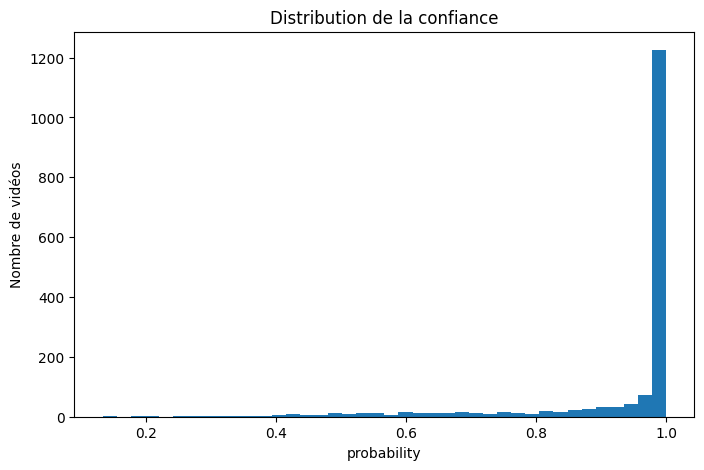

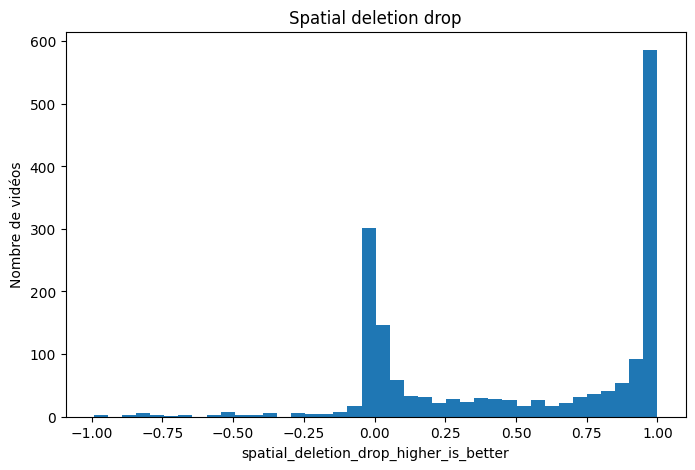

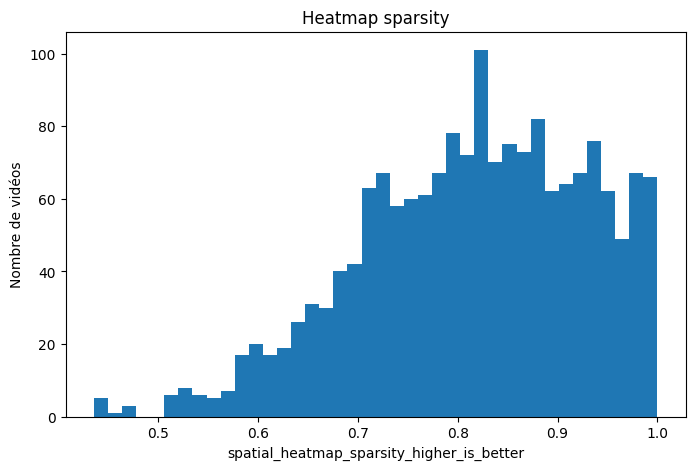

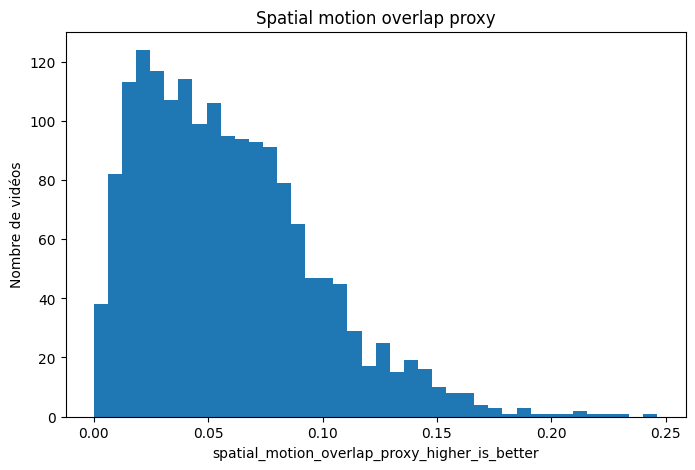

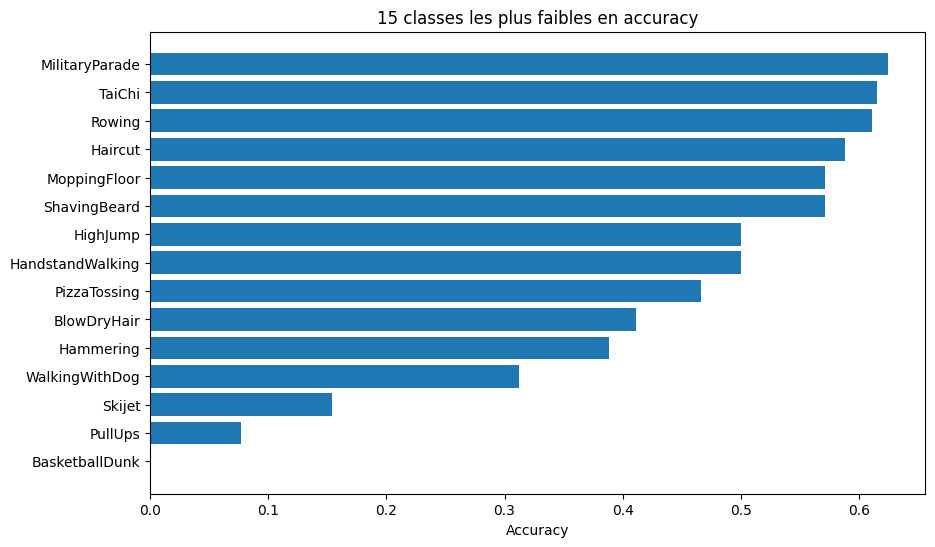

In [21]:
df_test = evaluate_full_split(
    checkpoint_path=checkpoint_path,
    split='test',
    max_samples=None
)

summary_df, class_summary = summarize_results(df_test)
plot_diagnostics(df_test, class_summary)